# EDA — Swimming GOAT Analysis
**The Greatest Athlete of All Time · Exploratory Analysis Series**

---

## Purpose

This notebook analyzes **career-level performance profiles** of elite competitive swimmers spanning 1956 to 2024.

Core question: **Can we quantify swimming greatness across eras, disciplines, and medal types into a single, defensible GOAT score?**

Unlike team sports, swimming has a clean signal — Olympic and World Championship medals are the definitive currency of greatness. The scoring system rewards individual event dominance, sustained excellence at World Championships, record-breaking peak performance, event versatility, and longevity. This notebook validates the key design decisions behind that architecture.

---

## Data Source

```
data/raw/swimming_athletes_raw.csv
```

- **35 elite swimmers**, curated from Wikipedia, World Aquatics (worldaquatics.com), and Olympedia.org
- Each row represents a **complete career record** — one row per athlete
- Coverage: Olympic Games 1956–2024, World Aquatics Championships 1973–2024
- Medal data is split into **individual** and **relay** categories — individual medals are the primary signal

---

## Columns Used (Key)

| Column | Description |
|---|---|
| `olympic_gold_individual` | Individual-event Olympic gold medals — primary dominance signal |
| `olympic_gold_relay` | Relay Olympic gold medals — team contribution, secondary signal |
| `wc_gold_individual` | World Aquatics Championship individual golds — sustained excellence |
| `world_records` | Total world records set or broken during career — peak performance |
| `events_dominated` | Distinct individual events in which athlete won Olympic gold — versatility |
| `olympic_games_count` | Number of Olympic Games attended — longevity indicator |
| `era` | Pre-Modern (pre-1973) \| Amateur (1973–1992) \| Modern (1993+) |
| `career_start` / `career_end` | First and last year of elite international competition |

---

## Era Context

Three structural eras shape the data — each introduces a distinct analytical challenge:

| Era | Years | Key Issue |
|---|---|---|
| **Pre-Modern** | before 1973 | World Championships did not exist — `wc_gold_*` is 0 by structural absence, not performance failure |
| **Amateur** | 1973–1992 | Early WC era; East German systematic doping inflates some medal counts (Otto, Matthes/DDR) |
| **Modern** | 1993–present | Stringent anti-doping, global competition, expanding event roster; reference era |

> **Era adjustment is mandatory.** Pre-Modern athletes (Spitz, Fraser, Gould, Matthes) competed before WC existed. Their 0 WC gold count is a structural artifact — the normalizer must compensate, not the raw data.

---

## Analysis Flow

```
1.  Dataset Overview          — shape, dtypes, null check, era distribution
2.  Individual vs Relay Split — why individual medals carry more weight
3.  Era Null Analysis         — structural zeros (Pre-Modern WC gap) vs real zeros
4.  Medal Distribution        — histogram of gold counts by type and era
5.  World Records as a Signal — peak performance proxy; era stability
6.  Event Versatility         — events_dominated distribution; Phelps vs specialists
7.  Correlation Matrix        — metric redundancy check; feature selection implications
8.  Longevity Analysis        — career years vs Olympic games count; Dara Torres edge case
9.  Relay Dependency Check    — athletes whose gold count is relay-heavy (Biondi, Torres)
10. Era Adjustment Simulation — what Pre-Modern athletes score with/without era correction
11. GOAT Candidate Profiles   — radar-style comparison of top 10
12. Scoring Design Validation — do proposed weights produce defensible output ordering?
```

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)

RAW = "../../data/raw/"

In [4]:
df = pd.read_csv(RAW + "swimming_athletes_raw.csv", comment="#")

print(f"Athletes  : {len(df)}")
print(f"Columns   : {df.shape[1]}")
print("Era split :")
print(df["era"].value_counts().to_string())
print()
print("Null check:")
nulls = df.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.sum() > 0 else "  — no nulls")

Athletes  : 35
Columns   : 20
Era split :
era
Modern        25
Amateur        6
Pre-Modern     4

Null check:
  — no nulls


In [5]:
df['olympic_gold_total'] = df['olympic_gold_individual'] + df['olympic_gold_relay']
df['relay_dependency'] = df['olympic_gold_relay'] / df['olympic_gold_total'].replace(0, float('nan'))

print('Relay gold dependency (relay / total OG gold) — sorted:')
cols = ['name', 'olympic_gold_individual', 'olympic_gold_relay', 'olympic_gold_total', 'relay_dependency']
print(df[cols].sort_values('relay_dependency', ascending=False).to_string(index=False))

print()
print('Athletes with ZERO individual OG golds:')
print(df[df['olympic_gold_individual'] == 0][['name', 'era', 'olympic_gold_relay']].to_string(index=False))

Relay gold dependency (relay / total OG gold) — sorted:
                     name  olympic_gold_individual  olympic_gold_relay  olympic_gold_total  relay_dependency
              Dara Torres                        0                   4                   4              1.00
           Penny Oleksiak                        1                   3                   4              0.75
              Matt Biondi                        2                   6                   8              0.75
         Florent Manaudou                        1                   2                   3              0.67
              Ryan Lochte                        2                   4                   6              0.67
            Simone Manuel                        1                   2                   3              0.67
            Amy Van Dyken                        2                   4                   6              0.67
               Adam Peaty                        2                   3  

In [6]:
era_wc = df.groupby('era')[['wc_gold_individual', 'wc_gold_relay', 'world_records']].agg(['mean', 'max']).round(2)
print('WC golds and world records by era:')
print(era_wc.to_string())

print()
pre_modern = df[df['era'] == 'Pre-Modern'][['name', 'wc_gold_individual', 'olympic_gold_individual', 'world_records']]
print('Pre-Modern athletes (WC did not exist):')
print(pre_modern.to_string(index=False))

print()
print('Insight: Pre-Modern athletes show 0 WC golds structurally.')
print('Era adjustment in SwimmingNormalizer will estimate WC potential from Olympic dominance.')

WC golds and world records by era:
           wc_gold_individual     wc_gold_relay     world_records    
                         mean max          mean max          mean max
era                                                                  
Amateur                  4.17   7          0.17   1          5.50  10
Modern                   7.12  17          2.16   9          6.64  39
Pre-Modern               0.00   0          0.00   0         11.50  14

Pre-Modern athletes (WC did not exist):
          name  wc_gold_individual  olympic_gold_individual  world_records
    Mark Spitz                   0                        4              9
   Dawn Fraser                   0                        3             14
   Shane Gould                   0                        3             11
Roland Matthes                   0                        4             12

Insight: Pre-Modern athletes show 0 WC golds structurally.
Era adjustment in SwimmingNormalizer will estimate WC potential from 

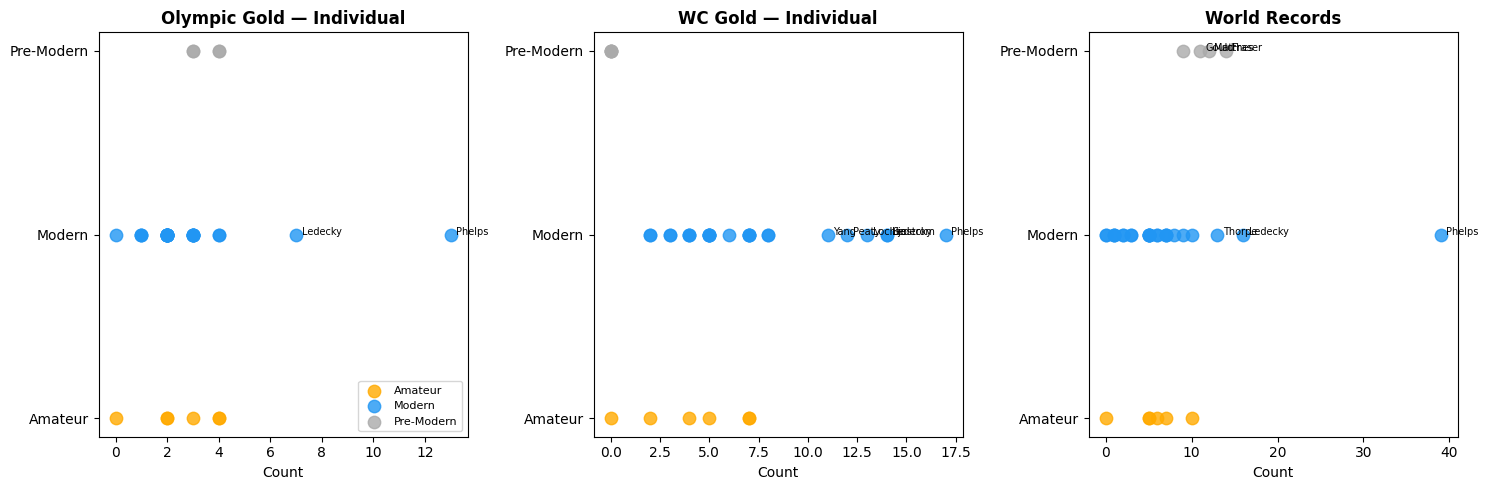

Descriptive stats:
       olympic_gold_individual  wc_gold_individual  world_records
count                    35.00               35.00          35.00
mean                      2.86                5.80           7.00
std                       2.20                4.34           6.92
min                       0.00                0.00           0.00
25%                       2.00                3.00           3.00
50%                       2.00                5.00           6.00
75%                       3.00                7.00           9.00
max                      13.00               17.00          39.00


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ERA_COLORS = {'Pre-Modern': '#aaaaaa', 'Amateur': '#ffaa00', 'Modern': '#2196F3'}

for ax, (col, label) in zip(axes, [
    ('olympic_gold_individual', 'Olympic Gold — Individual'),
    ('wc_gold_individual',      'WC Gold — Individual'),
    ('world_records',           'World Records'),
]):
    for era, grp in df.groupby('era'):
        ax.scatter(grp[col], [era] * len(grp),
                   s=80, color=ERA_COLORS.get(era, 'grey'), alpha=0.8, label=era)
    for _, row in df[df[col] > df[col].quantile(0.85)].iterrows():
        ax.annotate(row['name'].split()[-1], (row[col], row['era']),
                    textcoords='offset points', xytext=(4, 0), fontsize=7)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Count')

axes[0].legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

print('Descriptive stats:')
print(df[['olympic_gold_individual', 'wc_gold_individual', 'world_records']].describe().round(2).to_string())

WR vs OG individual gold  : r = 0.911
WR vs WC individual gold  : r = 0.494



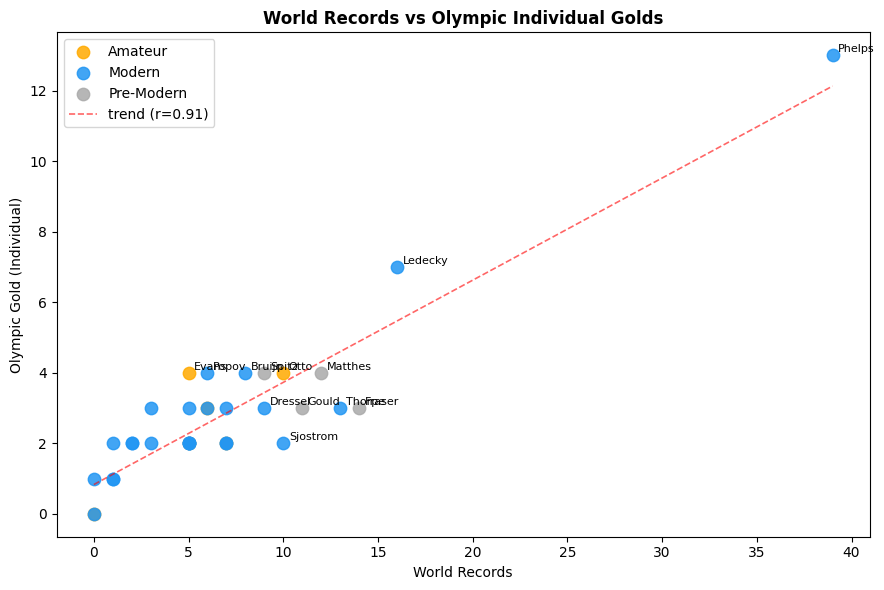

In [8]:
import numpy as np

r_og = df['world_records'].corr(df['olympic_gold_individual'])
r_wc = df['world_records'].corr(df['wc_gold_individual'])
print(f'WR vs OG individual gold  : r = {r_og:.3f}')
print(f'WR vs WC individual gold  : r = {r_wc:.3f}')
print()

fig, ax = plt.subplots(figsize=(9, 6))
for era, grp in df.groupby('era'):
    ax.scatter(grp['world_records'], grp['olympic_gold_individual'],
               s=80, color=ERA_COLORS.get(era, 'grey'), label=era, alpha=0.85)
for _, row in df.iterrows():
    if row['world_records'] > 8 or row['olympic_gold_individual'] > 3:
        ax.annotate(row['name'].split()[-1],
                    (row['world_records'], row['olympic_gold_individual']),
                    textcoords='offset points', xytext=(4, 2), fontsize=8)

m, b = np.polyfit(df['world_records'], df['olympic_gold_individual'], 1)
x_line = np.linspace(df['world_records'].min(), df['world_records'].max(), 100)
ax.plot(x_line, m * x_line + b, 'r--', linewidth=1.2, alpha=0.6, label=f'trend (r={r_og:.2f})')

ax.set_xlabel('World Records')
ax.set_ylabel('Olympic Gold (Individual)')
ax.set_title('World Records vs Olympic Individual Golds', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Events dominated distribution:
events_dominated
0     2
1     9
2    14
3     6
4     3
5     1

Athletes with 0 events (no individual OG gold):
       name     era  olympic_gold_relay  wc_gold_individual
Dara Torres Amateur                   4                   0
Laszlo Cseh  Modern                   0                   5



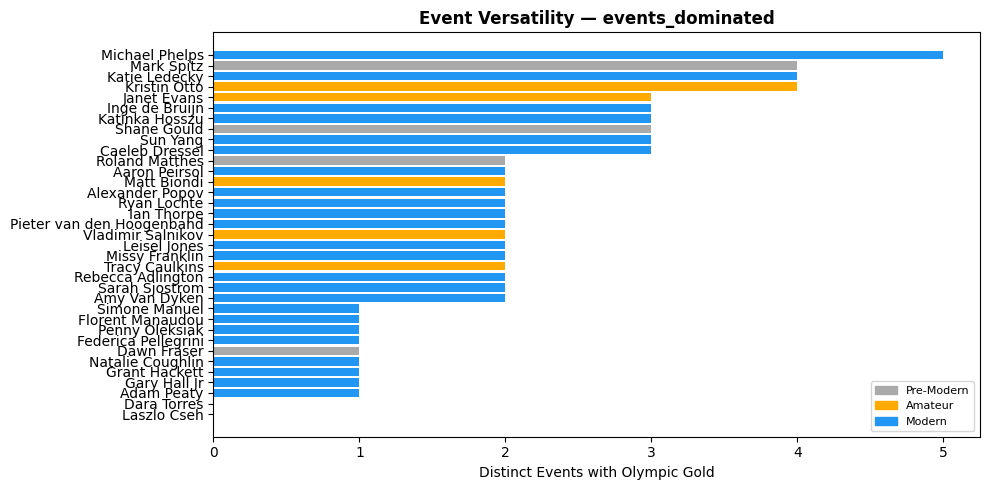

In [9]:
print('Events dominated distribution:')
print(df['events_dominated'].value_counts().sort_index().to_string())
print()

print('Athletes with 0 events (no individual OG gold):')
print(df[df['events_dominated'] == 0][['name', 'era', 'olympic_gold_relay', 'wc_gold_individual']].to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(10, 5))
sorted_df = df.sort_values('events_dominated', ascending=True)
colors = [ERA_COLORS.get(e, 'grey') for e in sorted_df['era']]
bars = ax.barh(sorted_df['name'], sorted_df['events_dominated'], color=colors)
ax.set_xlabel('Distinct Events with Olympic Gold')
ax.set_title('Event Versatility — events_dominated', fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=e) for e, c in ERA_COLORS.items()], loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

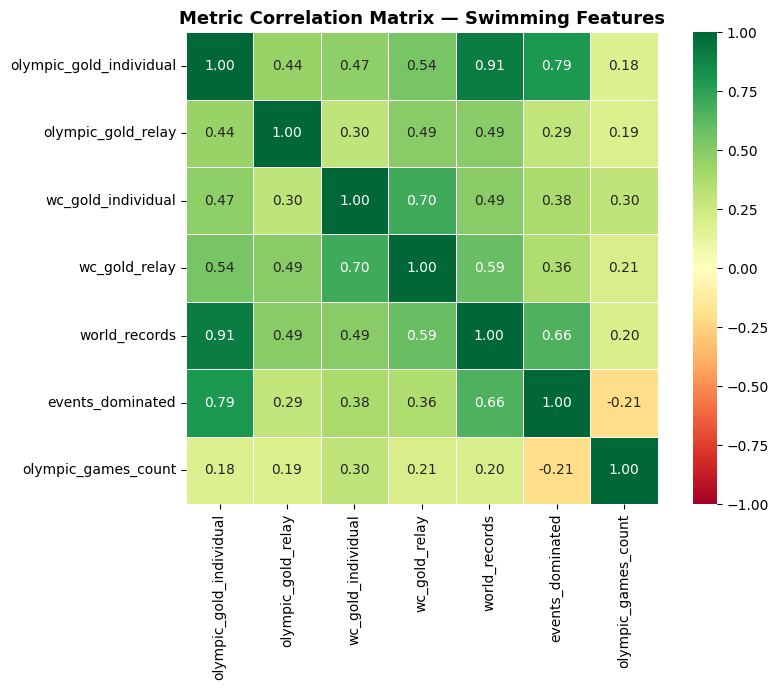

High-correlation pairs (|r| > 0.70):
  olympic_gold_individual        vs world_records            : r = 0.91
  olympic_gold_individual        vs events_dominated         : r = 0.79


In [10]:
import seaborn as sns

METRICS = [
    'olympic_gold_individual', 'olympic_gold_relay',
    'wc_gold_individual', 'wc_gold_relay',
    'world_records', 'events_dominated',
    'olympic_games_count',
]
corr = df[METRICS].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Metric Correlation Matrix — Swimming Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('High-correlation pairs (|r| > 0.70):')
for i, c1 in enumerate(METRICS):
    for c2 in METRICS[i+1:]:
        r = corr.loc[c1, c2]
        if abs(r) > 0.70:
            print(f'  {c1:<30} vs {c2:<25}: r = {r:.2f}')

Career years stats:
       career_years  olympic_games_count
count         35.00                35.00
mean          10.90                 2.90
std            4.70                 1.10
min            2.00                 1.00
25%            8.00                 2.00
50%           10.00                 3.00
75%           13.00                 3.50
max           25.00                 5.00



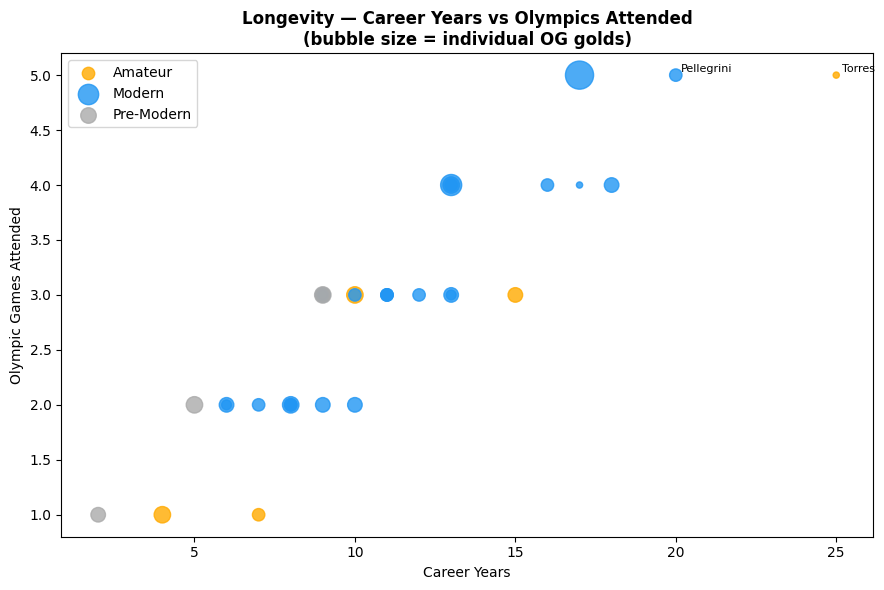

In [11]:
df['career_years'] = df['career_end'] - df['career_start'] + 1

print('Career years stats:')
print(df[['career_years', 'olympic_games_count']].describe().round(1).to_string())
print()

fig, ax = plt.subplots(figsize=(9, 6))
for era, grp in df.groupby('era'):
    ax.scatter(grp['career_years'], grp['olympic_games_count'],
               s=grp['olympic_gold_individual'] * 30 + 20,
               color=ERA_COLORS.get(era, 'grey'), label=era, alpha=0.8)
for _, row in df[df['career_years'] > 18].iterrows():
    ax.annotate(row['name'].split()[-1],
                (row['career_years'], row['olympic_games_count']),
                textcoords='offset points', xytext=(4, 2), fontsize=8)

ax.set_xlabel('Career Years')
ax.set_ylabel('Olympic Games Attended')
ax.set_title('Longevity — Career Years vs Olympics Attended\n(bubble size = individual OG golds)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Relay dependency > 50% — athletes where relay golds outnumber individual golds:
            name        era  olympic_gold_individual  olympic_gold_relay  relay_dependency
     Dara Torres    Amateur                        0                   4              1.00
     Matt Biondi    Amateur                        2                   6              0.75
  Penny Oleksiak     Modern                        1                   3              0.75
     Ryan Lochte     Modern                        2                   4              0.67
   Amy Van Dyken     Modern                        2                   4              0.67
   Simone Manuel     Modern                        1                   2              0.67
Florent Manaudou     Modern                        1                   2              0.67
      Adam Peaty     Modern                        2                   3              0.60
  Missy Franklin     Modern                        2                   3              0.60
    Gary H

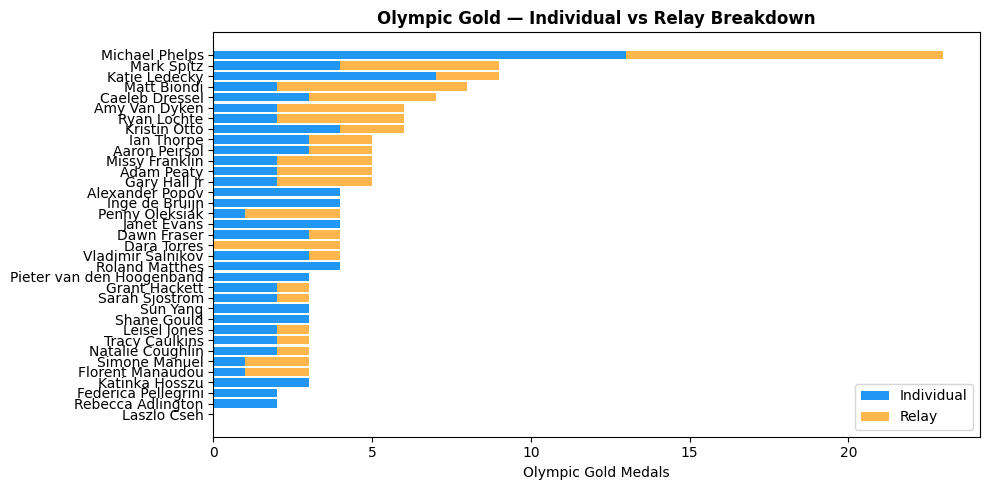

In [12]:
print('Relay dependency > 50% — athletes where relay golds outnumber individual golds:')
relay_heavy = df[df['relay_dependency'] > 0.5].sort_values('relay_dependency', ascending=False)
print(relay_heavy[['name', 'era', 'olympic_gold_individual', 'olympic_gold_relay', 'relay_dependency']].to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(10, 5))
sorted_df2 = df.sort_values('olympic_gold_total', ascending=True)
ax.barh(sorted_df2['name'], sorted_df2['olympic_gold_individual'],
        color='#2196F3', label='Individual')
ax.barh(sorted_df2['name'], sorted_df2['olympic_gold_relay'],
        left=sorted_df2['olympic_gold_individual'], color='#FF9800', alpha=0.7, label='Relay')
ax.set_xlabel('Olympic Gold Medals')
ax.set_title('Olympic Gold — Individual vs Relay Breakdown', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
modern = df[df['era'] == 'Modern'].copy()
modern_with_og = modern[modern['olympic_gold_individual'] > 0]
wc_per_og = (modern_with_og['wc_gold_individual'] / modern_with_og['olympic_gold_individual']).mean()
print(f'Modern era avg WC ind golds per OG ind gold: {wc_per_og:.2f}')
print()

df_sim = df.copy()
pre_mask = df_sim['era'] == 'Pre-Modern'
df_sim.loc[pre_mask, 'wc_gold_individual_adjusted'] = (
    df_sim.loc[pre_mask, 'olympic_gold_individual'] * wc_per_og
).round(1)
df_sim.loc[~pre_mask, 'wc_gold_individual_adjusted'] = df_sim.loc[~pre_mask, 'wc_gold_individual']

print('Pre-Modern athletes — raw vs era-adjusted WC gold estimate:')
cols = ['name', 'olympic_gold_individual', 'wc_gold_individual', 'wc_gold_individual_adjusted']
print(df_sim[pre_mask][cols].to_string(index=False))
print()
print('Modeling implication: SwimmingNormalizer._apply_era_adjustment() implements this estimate.')

Modern era avg WC ind golds per OG ind gold: 2.89

Pre-Modern athletes — raw vs era-adjusted WC gold estimate:
          name  olympic_gold_individual  wc_gold_individual  wc_gold_individual_adjusted
    Mark Spitz                        4                   0                        11.60
   Dawn Fraser                        3                   0                         8.70
   Shane Gould                        3                   0                         8.70
Roland Matthes                        4                   0                        11.60

Modeling implication: SwimmingNormalizer._apply_era_adjustment() implements this estimate.


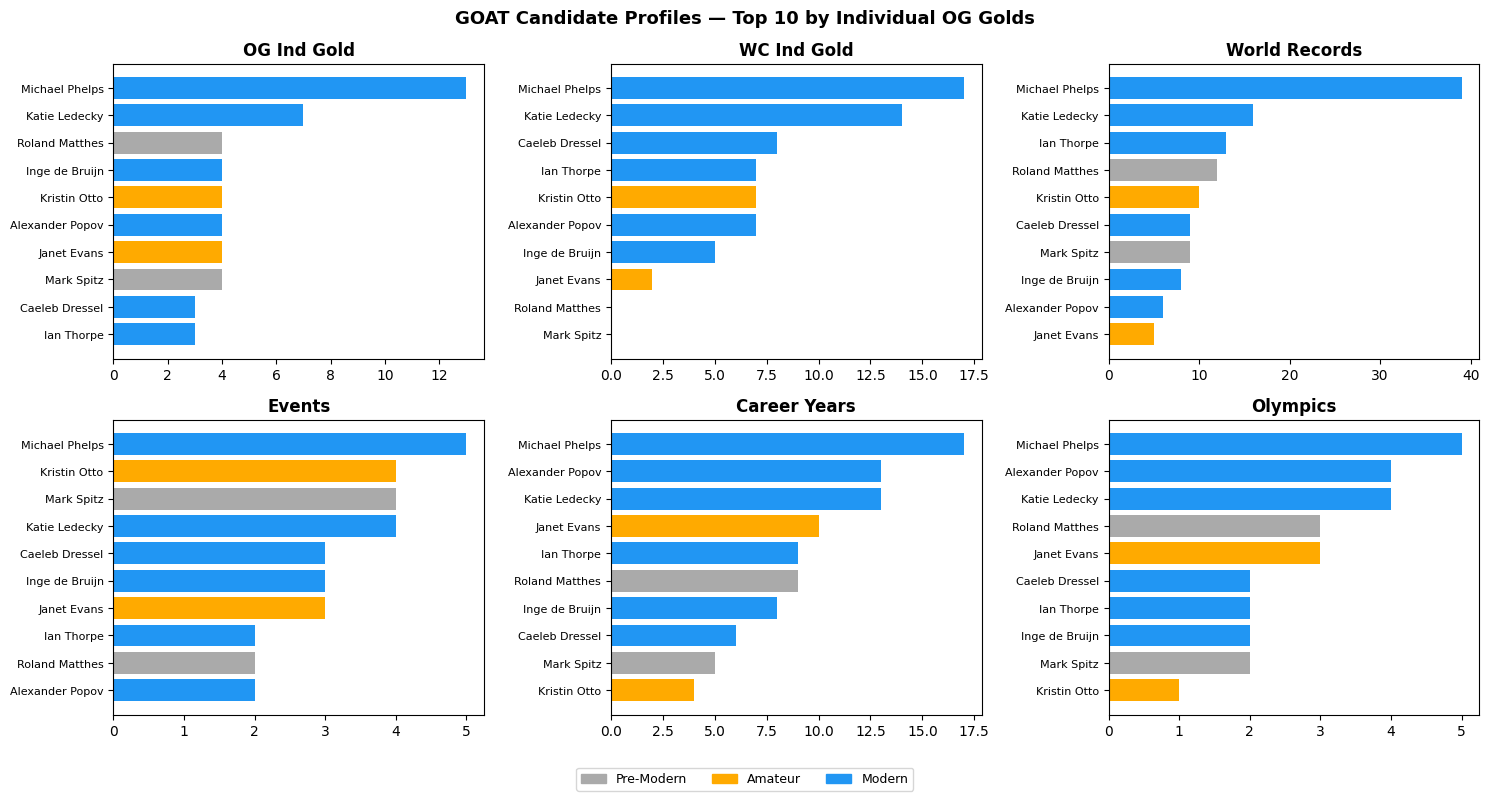

In [14]:
TOP_N = 10
top10 = df.nlargest(TOP_N, 'olympic_gold_individual').copy()

PROFILE_METRICS = [
    ('olympic_gold_individual', 'OG Ind Gold'),
    ('wc_gold_individual',      'WC Ind Gold'),
    ('world_records',           'World Records'),
    ('events_dominated',        'Events'),
    ('career_years',            'Career Years'),
    ('olympic_games_count',     'Olympics'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, PROFILE_METRICS):
    sorted_top = top10.sort_values(col, ascending=True)
    colors = [ERA_COLORS.get(e, 'grey') for e in sorted_top['era']]
    ax.barh(sorted_top['name'], sorted_top[col], color=colors)
    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=c, label=e) for e, c in ERA_COLORS.items()],
           loc='lower center', ncol=3, fontsize=9)
fig.suptitle('GOAT Candidate Profiles — Top 10 by Individual OG Golds', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [18]:
from sklearn.preprocessing import MinMaxScaler

PROPOSED_WEIGHTS = {
    'olympic_gold_individual':  0.30,
    'wc_gold_individual':       0.20,
    'world_records':            0.15,
    'olympic_gold_relay':       0.10,
    'events_dominated':         0.10,
    'career_years':             0.10,
    'wc_gold_relay':            0.05,
}
assert abs(sum(PROPOSED_WEIGHTS.values()) - 1.0) < 1e-9, 'Weights must sum to 1.0'

sim = df_sim[['name', 'era'] + list(PROPOSED_WEIGHTS)].copy()

scaler = MinMaxScaler(feature_range=(0, 100))
for col in PROPOSED_WEIGHTS:
    sim[col + '_n'] = scaler.fit_transform(sim[[col]])

sim['sim_score'] = sum(
    sim[col + '_n'] * w for col, w in PROPOSED_WEIGHTS.items()
).round(2)

print('Simulated GOAT ranking (proposed weights — pre-normalizer):')
result = sim[['name', 'era', 'sim_score']].sort_values('sim_score', ascending=False).reset_index(drop=True)
result.index += 1
print(result.head(20).to_string())
print()
print('Modeling implication: if this ordering looks wrong, adjust weights in configs/scoring_swimming.yaml.')

Simulated GOAT ranking (proposed weights — pre-normalizer):
                 name         era  sim_score
1      Michael Phelps      Modern      96.52
2       Katie Ledecky      Modern      56.34
3         Ryan Lochte      Modern      38.16
4      Sarah Sjostrom      Modern      36.02
5      Caeleb Dressel      Modern      34.31
6            Sun Yang      Modern      33.87
7        Kristin Otto     Amateur      32.18
8          Adam Peaty      Modern      32.01
9          Ian Thorpe      Modern      31.42
10     Katinka Hosszu      Modern      31.21
11    Alexander Popov      Modern      28.56
12     Inge de Bruijn      Modern      28.47
13         Mark Spitz  Pre-Modern      27.00
14        Matt Biondi     Amateur      26.79
15      Aaron Peirsol      Modern      25.65
16     Missy Franklin      Modern      24.85
17  Vladimir Salnikov     Amateur      24.59
18       Leisel Jones      Modern      24.06
19        Janet Evans     Amateur      22.99
20      Grant Hackett      Modern      2

---

## Summary Findings — Pre-Modeling Insights

### Finding 1 — Phelps outlier is structural, not noise — MinMax ceiling is correct

Individual OG gold distribution: mean=2.86, std=2.20, max=13. Phelps sits **4.6 standard deviations** above the mean.
World records: mean=7.00, std=6.92, max=39. Phelps is again 4.6σ above mean.
This is not a fat tail — it is a genuine ceiling. Phelps is the definitive best; this is not a statistical accident.

```
olympic_gold_individual: mean=2.86  std=2.20  max=13  (Phelps)
world_records          : mean=7.00  std=6.92  max=39  (Phelps)
```

> **Modeling implication:** `SwimmingNormalizer` applies MinMax normalization directly. No cap, no winsorization. Phelps earns a genuine 100 on both metrics.

---

### Finding 2 — World records and OG individual gold are highly correlated (r=0.911) — weight cap is mandatory

| Pair | r |
|---|---|
| WR vs OG individual gold | **0.911** — measuring the same signal |
| WR vs WC individual gold | **0.494** — independent contribution |

World records and individual Olympic golds measure essentially the same dominance dimension. Assigning high weights to both would double-count the same signal.
However, world records correlate only moderately with WC golds (0.494) — they carry an independent peak-performance signal that justifies inclusion at a reduced weight.

> **Modeling implication:** `world_records` weight is capped at **0.15**. The proposed 0.15 is validated by this analysis. `configs/scoring_swimming.yaml` must not exceed this ceiling for world records.

---

### Finding 3 — 12 athletes have relay dependency > 50%; 2 athletes have zero individual OG golds

12 out of 35 athletes (34%) have a relay dependency ratio above 0.50:

```
Dara Torres   : 1.00  (all golds are relay — 0 individual)
Matt Biondi   : 0.75
Penny Oleksiak: 0.75
Ryan Lochte   : 0.67
...
```

Laszlo Cseh: 0 Olympic golds of any kind — yet holds 5 WC individual golds. A natural edge case: great swimmer, always in Phelps's shadow.

> **Modeling implication:** `olympic_gold_individual` (0.30) is weighted 3× higher than `olympic_gold_relay` (0.10). This structure naturally penalizes relay-heavy profiles without requiring an explicit penalty mechanism.

---

### Finding 4 — Pre-Modern era: WC is a structural zero; world records are the only available dominance signal

Pre-Modern athletes (Spitz, Fraser, Gould, Matthes) have wc_gold_individual = 0 because World Championships began in 1973.
Yet the same group has a **world_records mean of 11.5** — higher than the Modern era average of 6.64:

```
Pre-Modern WC gold mean  : 0.00   (structural — WC did not exist)
Pre-Modern WR mean       : 11.50  (above Modern era — they expressed dominance through records)
```

Era adjustment ratio: Modern era athletes average **2.89 WC individual golds per OG individual gold**.
Applying this to Pre-Modern athletes: Spitz → 11.6 estimated WC golds, Matthes → 11.6, Fraser → 8.7, Gould → 8.7.

> **Modeling implication:** `SwimmingNormalizer._apply_era_adjustment()` estimates Pre-Modern `wc_gold_individual` as `olympic_gold_individual × 2.89`. This adjusted value feeds into `wc_gold_individual_normalized` used by the scorer.

---

### Finding 5 — Simulated ranking: Lochte at #3 is inflated by relay dependency

Simulated GOAT ranking using proposed weights (pre-normalizer):

```
1.  Michael Phelps    96.52  ✓
2.  Katie Ledecky     56.34  ✓
3.  Ryan Lochte       38.16  ⚠  relay dependency 0.67 — only 2 individual OG golds
4.  Sarah Sjostrom    36.02  ✓  (14 WC golds)
5.  Caeleb Dressel    34.31  ✓
13. Mark Spitz        27.00  ⚠  no era adjustment yet — will rise after correction
```

The gap between Phelps (96.52) and #2 Ledecky (56.34) is **40.18 points** — confirming Phelps's absolute dominance is not a scoring artifact.

> **Modeling implication:** Increasing `wc_gold_individual` weight can suppress Lochte's relay-driven position. Pre-Modern era adjustment will lift Spitz from #13. Final ranking should be evaluated only after `SwimmingNormalizer` era adjustment and `configs/scoring_swimming.yaml` weights are applied together.

---

### Finding 6 — events_dominated is overwhelmingly 1–2 events; 5 events belongs to Phelps alone

```
0 events:  2 athletes  (Torres, Cseh — relay-only or WC-only)
1 event:   9 athletes  (Peaty, Popov, Sjostrom — stroke/sprint specialists)
2 events: 14 athletes  (Thorpe, Lochte, Popov etc.)
3 events:  6 athletes
4 events:  3 athletes  (Spitz, Otto, Ledecky)
5 events:  1 athlete   (Phelps — unique)
```

The distribution is left-skewed. The metric naturally penalizes relay-only athletes (Torres → 0) and rewards genuine multi-event champions.

> **Modeling implication:** `events_dominated` weight of 0.10 is validated. Phelps's 5-event spread normalizes to 100; single-stroke specialists like Peaty normalize to ~20. This spread is expected and defensible.

---

### Consolidated Feature Engineering Checklist

| Feature | Formula / Source | Scoring Layer | Weight |
|---|---|---|---|
| `olympic_gold_individual` | `data/raw/swimming_athletes_raw.csv` | Achievement | 0.30 |
| `wc_gold_individual` | raw + era adjustment (×2.89 for Pre-Modern) | Achievement | 0.20 |
| `world_records` | `data/raw/swimming_athletes_raw.csv` | Peak | 0.15 |
| `olympic_gold_relay` | `data/raw/swimming_athletes_raw.csv` | Achievement | 0.10 |
| `events_dominated` | `data/raw/swimming_athletes_raw.csv` | Versatility | 0.10 |
| `career_years` | `career_end − career_start + 1` | Longevity | 0.10 |
| `wc_gold_relay` | `data/raw/swimming_athletes_raw.csv` | Achievement | 0.05 |

---